In [1]:
import re
import matplotlib
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

import matplotlib.pyplot as plt

import io
from IPython.display import Image, display
import utils
import nist_codes

import matplotlib.patheffects as pe

import new_utils


In [2]:
X_MIN = 400
X_MAX = 750
FIG_SIZE = (15,3)
MIN_NEEDLE_WIDTH = 0.1
MAX_NEEDLE_WIDTH = 0.3
DPI = 600
MAX_Y_SCALE = 0.75
NEEDLE_POWER_SHAPE = 4
LABEL_NORM_INT = 0.20
GLOW_WIDTH_MULT = 1.3

NORM_PROM_PERC = 0.15
NORM_MIN_BRIGHT = 0.01
NORM_GLOW_ALPHA = 0
NORM_PEAK_EMPHASIS = 1.1
NORM_PEAK_LABEL_POSN = 0.75

DEFAULT_PROM_PERC = 0.08
DEFAULT_MIN_BRIGHT = 0.1
DEFAULT_GLOW_ALPHA = 0.35
DEFAULT_PEAK_EMPHASIS = 1.4
DEFAULT_PEAK_LABEL_POSN = 0.77

detection_col = '_raw_int'
int_col = '_adj_int'

In [3]:
def res_col_names(
    data_df,
    nm_col = None,
    int_col = None,
):
    global wl_col
    global INT_col
    if nm_col is None:
        wl_col = utils.resolve_column(data_df, utils.lambda_tokens, "wavelength",)
    if int_col is None:
        INT_col = utils.resolve_column(data_df, utils.int_tokens, "intensity",)

    print(wl_col, INT_col)
    
    return data_df, wl_col, INT_col

In [4]:
H_SHEET = "h test.xlsx"

df = pd.read_excel(H_SHEET)

res_col_names(data_df=df, nm_col=None, int_col=None)

nm Grey Val


(     Unnamed: 0  Grey Val         nm
 0           NaN     8.367  774.51129
 1           NaN     9.796  773.38503
 2           NaN     9.329  772.25877
 3           NaN     9.808  771.13251
 4           NaN     9.646  770.00625
 ..          ...       ...        ...
 495         NaN     5.896  217.01259
 496         NaN     7.062  215.88633
 497         NaN     9.217  214.76007
 498         NaN     9.083  213.63381
 499         NaN     8.012  212.50755
 
 [500 rows x 3 columns],
 'nm',
 'Grey Val')

In [5]:
""" doesn't work if there's any extra spaces or anything in the excel header
e.g. if nm_col finds "nm " instead of "nm", it breaks
"""


# default df_filtered
df_filtered = df[(df[wl_col] >= 400) & (df[wl_col] <= 750)].copy()
df_filtered = df_filtered.sort_values(by=wl_col).reset_index(drop=True)
print("DataFrame loaded successfully. Here are the first 5 rows:")
print(df.head())


# smoothed df_filtered
df_filtered['Smoothed_int'] = df_filtered[INT_col].rolling(window=new_utils.smoothing_window, center=True).mean().fillna(df_filtered[INT_col])

if new_utils.plot_type == 'Smoothed':
    min_int = df_filtered['Smoothed_int'].min
    max_int = df_filtered['Smoothed_int'].max
else:
    min_int = df_filtered[INT_col].min()
    max_int = df_filtered[INT_col].max()

int_range = max_int - min_int

if int_range == 0:
    df_filtered['Normalized_int'] = 1.0
else:
    if new_utils.plot_type == 'Smoothed':
        df_filtered['Normalized_int'] = (df_filtered['Smoothed_int'] - min_int) / int_range
    else:
        df_filtered['Normalized_int'] = (df_filtered[INT_col] - min_int) / int_range


DataFrame loaded successfully. Here are the first 5 rows:
   Unnamed: 0  Grey Val         nm
0         NaN     8.367  774.51129
1         NaN     9.796  773.38503
2         NaN     9.329  772.25877
3         NaN     9.808  771.13251
4         NaN     9.646  770.00625


In [6]:
def get_mode():
    global mode
    inp = input("Choose Mode: Dark or Light").lower()
    if inp == 'dark' or inp == 'd':
        mode = 'dark'
    elif inp == 'light' or inp == 'l':
        mode = 'light'
    print("mode:", mode)
    return mode

def dynamic_prominence(prominence, int_range):
    dyn_prom = prominence * int_range
    return dyn_prom

# for final_alpha AND final_intensity_scale
def final_scale(min, factor):
    final = min + (1 - min) * factor
    return final

def colored_rgb(base_rgb, final_intensity_scale):
    colored_rgb = (base_rgb[0] * final_intensity_scale,
                   base_rgb[1] * final_intensity_scale,
                   base_rgb[2] * final_intensity_scale)
    return colored_rgb

def text_colour():
    global colour
    global bg
    if mode == 'dark':
        colour = 'white'
        bg = 'black'
    if mode == 'light':
        colour = 'black'
        bg = 'white'
    print ("text colour:", colour,"face/bg colour:", bg)
    return colour, bg

def axis_labels(
    fig_size = (15, 6),
    show_grid = True,
    reverse_x = None,
    x_min = 400,
    x_max = 750,
    x_title = "Wavelength (nm)",
    y_title = "Intensity",
    text = None,
):
    
    plt.figure(figsize=fig_size)
    ax = plt.gca()
    get_mode()
    text_colour()
    print ("text colour:", colour, "bg colour:", bg, "mode:", mode)

    if mode == 'dark' or mode == 'd':
        fig_bg = bg
        text = colour
        plt.gcf().set_facecolor(fig_bg)
        if show_grid is True:
            plt.grid(show_grid, color='darkgrey', linestyle=':', linewidth=0.5)
    else:
        fig_bg = bg
        text = colour
        if show_grid is True:
            plt.grid(show_grid)
    
    reverse_x = (input("Reverse x-axis? Yes or No")).lower()
    if reverse_x == 'yes' or reverse_x == 'y':
        reverse_x is True
        plt.xlim(x_max, x_min)
    else:
        reverse_x is False
        plt.xlim(x_min, x_max)

    ax.set_facecolor(fig_bg)
    plt.xlabel(x_title, color=text)
    plt.ylabel(y_title, color=text)
    plt.xticks(color=text)
    plt.yticks(color=text)


In [7]:
def trad_spec_labels(    
    fig_size = (15, 3),
    reverse_x = None,
    x_min = 400,
    x_max = 750,
    x_title = "Wavelength (nm)",
    text_color = None,
    dpi = DPI,
):

    get_mode()
    text_colour()
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)

            # Set figure background and text colors based on mode
    if mode == 'dark':
        figure_bg_color = 'black'
        text_color = colour
    elif mode == 'light':
        figure_bg_color = 'white'
        text_color = colour
    print("mode:", mode, ", fig bg colour:", figure_bg_color)

    reverse_x = input(print("Reverse x-axis? Yes or No")).lower()
    if reverse_x == 'yes' or reverse_x == 'y':
        reverse_x is True
        plt.xlim(x_max, x_min)
    else:
        reverse_x is False
        plt.xlim(x_min, x_max)

    fig.patch.set_facecolor(figure_bg_color)
    ax.set_facecolor('black')  # Always keep the spectrum plot area (axes) background black

    # Remove Y-axis completely as intensity is shown by brightness/color
    ax.yaxis.set_visible(False)

    # Set X-axis labels and color
    ax.set_xlabel(x_title, color=text_color)

    # Set major and minor tick locators
    ax.xaxis.set_major_locator(utils.major_locator)
    ax.xaxis.set_minor_locator(utils.minor_locator)

    # Set tick parameters for both major and minor ticks
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)

    # Set X-axis limits
    ax.set_xlim(X_MIN, X_MAX)

    ax.set_ylim(0,1)

    return fig, text_color

In [8]:
def plot_spec(
    data_df,
    prominence_percentage=0,
    nm_col = None,
    int_col = None,
    x_min=X_MIN,
    x_max=X_MAX,
    fig_size=FIG_SIZE,
    min_brightness=0,
    min_needle_max_width_nm=MIN_NEEDLE_WIDTH,
    max_needle_max_width_nm=MAX_NEEDLE_WIDTH,
    needle_shape_power=NEEDLE_POWER_SHAPE,
    glow_width_multiplier=GLOW_WIDTH_MULT,
    glow_alpha=0,
    dpi=DPI,
    peak_label_y_position=0,
    max_needle_y_scale=MAX_Y_SCALE,
    peak_wavelengths=None,
    force_nist=None,
    apply_descriptor_adjustments=False,
    show_peak_labels=True,
    label_min_norm_int=LABEL_NORM_INT,
    generic_type=None
):
    
    get_mode()
    text_colour()

    res_col_names(data_df, nm_col=nm_col, int_col=int_col)

    # Always parse NIST-style intensity cells first because descriptors are usually attached.
    df_plot_data = data_df.copy()
    df_plot_data[wl_col] = pd.to_numeric(df_plot_data[wl_col], errors='coerce')

    # run NIST detector
    has_any_nist, nist_diag = nist_codes.detect_nist_values(df_plot_data[INT_col], force_nist=force_nist)

    if has_any_nist:
        df_plot_data = nist_codes.prepare_nist_spectrum(df_plot_data, INT_col, apply_descriptor_adjustments)
        min_brightness = DEFAULT_MIN_BRIGHT
        glow_alpha = DEFAULT_GLOW_ALPHA
        prominence_percentage = DEFAULT_PROM_PERC
        peak_label_y_position = DEFAULT_PEAK_LABEL_POSN
        print('NIST Destriptors Detected. Preparing NIST Rendering.')

    else:
        df_plot_data = utils.prepare_generic_spectrum(df_plot_data, INT_col, apply_descriptor_adjustments)
        print('No NIST Destriptors Detected. Preparing Generic Rendering.')
        generic_type = (input('Choose Rendering: Raw or Normalised')).lower()
        if generic_type == 'raw':
            glow_alpha = DEFAULT_GLOW_ALPHA
            peak_label_y_position = DEFAULT_PEAK_LABEL_POSN
        elif generic_type == 'normalised':
            glow_alpha = NORM_GLOW_ALPHA
            peak_label_y_position = NORM_PEAK_LABEL_POSN

        # parse NIST-style cells
    parsed_intensity = df_plot_data[INT_col].apply(nist_codes.parse_nist_intensity)
    df_plot_data['_raw_int'] = parsed_intensity.apply(lambda t: t[0])
    df_plot_data['_descriptor'] = parsed_intensity.apply(lambda t: t[1])

    # drop rows missing wavelength or numeric intensity
    df_plot_data = df_plot_data.dropna(subset=[wl_col, '_raw_int']).copy()
    df_plot_data = df_plot_data[(df_plot_data[wl_col] >= x_min) & (df_plot_data[wl_col] <= x_max)].copy()
    df_plot_data = df_plot_data.sort_values(by=wl_col).reset_index(drop=True)

    # returns empty figure for empty datasets
    if df_plot_data.empty:
        fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)
        ax.set_axis_off()
        return fig

    # Normalize using the adjusted intensity
    min_int_val = df_plot_data['_adj_int'].min()
    max_int_val = df_plot_data['_adj_int'].max()
    int_range = max_int_val - min_int_val
    if int_range == 0 or np.isnan(int_range):
        df_plot_data['Norm_Int'] = 1.0
    else:
        df_plot_data['Norm_Int'] = (df_plot_data['_adj_int'] - min_int_val) / int_range

    if peak_wavelengths is not None:
        nm_vals = df_plot_data[wl_col].values
        peaks = []
        for pw in peak_wavelengths:
            try:
                pv = float(pw)
            except Exception:
                continue
            idx = int(np.argmin(np.abs(nm_vals - pv)))
            peaks.append(idx)
        peaks = sorted(set(peaks))
    elif has_any_nist:
        peaks = nist_codes.identify_spectral_peaks(df_plot_data.reset_index(drop=True), prominence_percentage, peak_wavelengths=None)
    else:
        raw_min = df_plot_data[detection_col].min()
        raw_max = df_plot_data[detection_col].max()
        raw_range = raw_max - raw_min
        if generic_type=='raw':
            prominence_percentage = DEFAULT_PROM_PERC
        if generic_type == 'normalised':
            prominence_percentage = NORM_PROM_PERC
        dynamic_prominence = prominence_percentage * (raw_range if raw_range != 0 else 1.0)
        peaks, _ = find_peaks(df_plot_data[INT_col], prominence=dynamic_prominence)
    
    peak_nms = [float(df_plot_data.iloc[index][wl_col]) for index in peaks]
    peak_ints = [float(df_plot_data.iloc[index]["Norm_Int"]) for index in peaks]
    try:
        label_ys = utils.compute_label_positions(
            peak_nms,
            intensities=peak_ints,
            base_y=peak_label_y_position,
            min_sep_nm=0.4,
            y_step=0.08,
            method="prefer_stronger_top",
            max_y=0.90,
        )
    except Exception:
        label_ys = [peak_label_y_position] * len(peaks)
    
    print(f"DEBUG: max_label_y = {max(label_ys) if label_ys else 'N/A'}")

    # Create the plot (use explicit Figure/Axis to avoid side-effects)
    fig, ax = plt.subplots(figsize=fig_size, dpi=dpi)


    max_label_y = max(label_ys) if label_ys else peak_label_y_position
    print(f"DEBUG: max_label_y = {max_label_y:.3f}, fig height = {fig.get_figheight():.2f}")

    # More aggressive expansion
    ylim_upper = max(1.05, max_label_y + 0.25)
    ax.set_ylim(0, ylim_upper)
    fig.set_figheight(fig_size[1] + 0.8)
    print(f"DEBUG: new ylim upper = {ylim_upper:.3f}, new fig height = {fig.get_figheight():.2f}")

        # Set figure background and text colors based on mode
    if mode == 'dark':
        figure_bg_color = 'black'
        text_color = colour
    elif mode == 'light':
        figure_bg_color = 'white'
        text_color = colour
    print(figure_bg_color)

    fig.patch.set_facecolor(figure_bg_color)
    ax.set_facecolor('black')  # Always keep the spectrum plot area (axes) background black

    # Remove Y-axis completely as intensity is shown by brightness/color
    ax.yaxis.set_visible(False)

    # Set X-axis labels and color
    ax.set_xlabel('Wavelength (nm)', color=text_color)

    # Set major and minor tick locators
    ax.xaxis.set_major_locator(utils.major_locator)
    ax.xaxis.set_minor_locator(utils.minor_locator)

    # Set tick parameters for both major and minor ticks
    ax.tick_params(axis='x', which='major', colors=text_color, labelsize=10)
    ax.tick_params(axis='x', which='minor', colors=text_color, length=4, width=0.5)

    # Set X-axis limits
    ax.set_xlim(x_min, x_max)

    ax.set_ylim(0,1)

    # Render every transition as a faint needle (increase visibility for verification)
    _bg_y_top = max_needle_y_scale  # use full height for visibility
    _bg_y = np.linspace(0, _bg_y_top, 40)
    for _idx, _row in df_plot_data.iterrows():
        _nm = float(_row[wl_col])
        _ni = float(_row.get('Norm_Int', 0.0))
        _base_rgb = new_utils.rgb(_nm)
        _final_scale = min_brightness + (1 - min_brightness) * _ni
        _color = (_base_rgb[0] * _final_scale, _base_rgb[1] * _final_scale, _base_rgb[2] * _final_scale)
        _width_mult = float(_row.get('_width_mult', 1.0))
        _bg_base_width = min_needle_max_width_nm * 1.0 * _width_mult   # make background lines thicker for test
        _bg_widths = _bg_base_width * np.ones_like(_bg_y)
        _x_left = _nm - _bg_widths / 2
        _x_right = _nm + _bg_widths / 2
        ax.fill_betweenx(_bg_y, _x_left, _x_right, facecolor=_color, alpha=glow_alpha, edgecolor='none', linewidth=0, zorder=0)

    # Plot sharp distinct lines for each identified peak using fill_betweenx for needle shape
    for j, peak_index in enumerate(peaks):
        peak_nm = df_plot_data.iloc[peak_index][wl_col]
        peak_norm_int = df_plot_data.iloc[peak_index]['Norm_Int']

        # Get base RGB color for the peak wavelength
        base_rgb = new_utils.rgb(peak_nm)

        # Emphasize peaks: gentle gamma + emphasis multiplier for labeled peaks
        _peak_gamma = 0.8
        if has_any_nist or generic_type == 'raw':
            _peak_emphasis = DEFAULT_PEAK_EMPHASIS
            min_brightness = DEFAULT_MIN_BRIGHT
        elif generic_type == 'normalised':
            _peak_emphasis = NORM_PEAK_EMPHASIS
            min_brightness = NORM_MIN_BRIGHT
        pre_int_scale = min_brightness + (1 - min_brightness) * (peak_norm_int ** _peak_gamma)
        final_int_scale = min(1.0, pre_int_scale * _peak_emphasis)

        color_rgb = colored_rgb(base_rgb, final_int_scale)

        # Scale the maximum width of the needle based on normalized intensity

        base_width = min_needle_max_width_nm + (max_needle_max_width_nm - min_needle_max_width_nm) * peak_norm_int
        width_mult = df_plot_data.iloc[peak_index].get('_width_mult', 1.0)
        # boost peak widths so labeled peaks stand out
        _peak_width_boost = 1.6
        scaled_max_width_nm = base_width * width_mult * _peak_width_boost

        # Calculate the actual height the needle should reach (fraction of 0-1)
        current_peak_render_height = max_needle_y_scale

        # Define y-coordinates for the needle shape, spanning from 0 to current_peak_render_height
        y_coords_render = np.linspace(0, current_peak_render_height, 120)
        # Calculate normalized y-coordinates for the width profile
        y_coords_normalized_for_width = (
            y_coords_render / current_peak_render_height if current_peak_render_height > 0 else np.zeros_like(y_coords_render)
        )

        # Use a power-law profile for the width, making tips slimmer
        width_profile_factor = (4 * y_coords_normalized_for_width * (1 - y_coords_normalized_for_width)) ** needle_shape_power

        # --- Plot the GLOW effect first ---
        glow_current_widths_nm = scaled_max_width_nm * glow_width_multiplier * width_profile_factor
        glow_x_left = peak_nm - glow_current_widths_nm / 2
        glow_x_right = peak_nm + glow_current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            glow_x_left,
            glow_x_right,
            facecolor=color_rgb,
            alpha=glow_alpha,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=1,
        )

        # --- Plot the main NEEDLE on top of the glow ---
        current_widths_nm = scaled_max_width_nm * width_profile_factor
        x_left = peak_nm - current_widths_nm / 2
        x_right = peak_nm + current_widths_nm / 2
        ax.fill_betweenx(
            y_coords_render,
            x_left,
            x_right,
            facecolor=color_rgb,
            edgecolor='none',
            linewidth=0,
            antialiased=True,
            zorder=2,
        )

        # Add text label for the peak wavelength with rotation and stroke for readability
        if show_peak_labels and peak_norm_int >= label_min_norm_int:
            y_for_label = label_ys[j] if j < len(label_ys) else peak_label_y_position
            ax.text(
                peak_nm,
                y_for_label,
                f"{peak_nm:.2f}",
                color="white",
                ha="left",
                va="bottom",
                fontsize=8,
                rotation=60,
                rotation_mode="anchor",
                zorder=3,
                path_effects=[pe.withStroke(linewidth=1.5, foreground="black")],
            )

    if has_any_nist or generic_type == 'raw':
        pad = 15
    else:
        pad = 10
    plt.tight_layout(rect=[0, 0, 1, 0.92])
    plt.title(f'Emission Spectrum Visualization ({mode.capitalize()} Mode)', 
          color=text_color, y=0.98, pad=pad)


    return fig

In [9]:
def get_spec(*args, headless=True, dpi=600, **kwargs):
    if headless:
        matplotlib.use('Agg')

    fig = plot_spec(*args, **kwargs)

    if headless:
        plt.close(fig)

    return fig

In [10]:
def line_plot_iteration():  
    
    for i in range(len(df_filtered) - 1):
        wavelength_start = df_filtered.iloc[i][wl_col]
        wavelength_end = df_filtered.iloc[i+1][wl_col]

        int_factor = df_filtered.iloc[i]['Normalized_int']
        base_rgb = new_utils.rgb(wavelength_start)
        final_intensity_scale = new_utils.final_scale(new_utils.min_bright, int_factor)
        
        color_rgb = new_utils.colored_rgb(base_rgb, final_intensity_scale)

        plt.plot([wavelength_start, wavelength_end],
                [df_filtered.iloc[i][INT_col], df_filtered.iloc[i+1][INT_col]],
                color=color_rgb,
                linewidth=2)
    

def filled_plot():
    
    for i in range(len(df_filtered) - 1):
        wavelength_start = df_filtered.iloc[i][wl_col]
        wavelength_end = df_filtered.iloc[i+1][wl_col]

        base_rgb = new_utils.rgb(wavelength_start)

        alpha_factor = df_filtered.iloc[i]['Normalized_int']
        alpha = new_utils.final_scale(new_utils.min_alpha, alpha_factor)

        if new_utils.plot_type == 'Smoothed':
            plt.fill_between([wavelength_start, wavelength_end],
                     [0, 0], # Base of the fill is y=0
                     [df_filtered.iloc[i]['Smoothed_int'], df_filtered.iloc[i+1]['Smoothed_int']], # Top of the fill
                     color=base_rgb,
                     alpha=alpha,
                     linewidth=0) # No line for the fill edges
        else:
            plt.fill_between([wavelength_start, wavelength_end],
                        [0, 0], # Base of the fill is y=0
                        [df_filtered.iloc[i][INT_col], df_filtered.iloc[i+1][INT_col]], # Top of the fill
                        color=base_rgb,
                        alpha=alpha,
                        linewidth=0) # No line for the fill edges

            # Plot the line on top for clarity, using the base color for the line itself
            plt.plot([wavelength_start, wavelength_end],
                    [df_filtered.iloc[i][INT_col], df_filtered.iloc[i+1][INT_col]],
                    color=base_rgb,
                    linewidth=2) # Thicker line for better visibility on top of fill
            

def gaussian_iteration():

    # Detect peaks
    dyn_prominence = new_utils.dynamic_prominence(new_utils.prominence, int_range)
    peaks_indices, properties = find_peaks(df_filtered[INT_col], prominence=dyn_prominence)

    # Create a new, denser wavelength array for plotting the synthetic spectrum
    x_synthetic = np.linspace(400, 750, 1000) # 1000 points for a smooth synthetic curve
    y_synthetic = np.zeros_like(x_synthetic)

    for i, peak_idx in enumerate(peaks_indices):
        peak_nm = df_filtered.iloc[peak_idx][wl_col]
        peak_amplitude = df_filtered.iloc[peak_idx][INT_col]
        normalized_amplitude = df_filtered.iloc[peak_idx]['Normalized_int']

        # Scale sigma based on normalized intensity (higher intensity = broader peak)
        sigma = new_utils.base_sigma_nm + (new_utils.max_sigma_multiplier - 1) * new_utils.base_sigma_nm * normalized_amplitude

        # Create a Gaussian curve for this peak
        gaussian_curve = peak_amplitude * np.exp(-((x_synthetic - peak_nm)**2) / (2 * sigma**2))
        y_synthetic += gaussian_curve # Add to the total synthetic spectrum

    # Normalize the synthetic spectrum intensities for coloring (if desired, not strictly necessary for area plot)
    min_y_synthetic = y_synthetic.min()
    max_y_synthetic = y_synthetic.max()
    if (max_y_synthetic - min_y_synthetic) == 0:
        normalized_y_synthetic = np.ones_like(y_synthetic)
    else:
        normalized_y_synthetic = (y_synthetic - min_y_synthetic) / (max_y_synthetic - min_y_synthetic)

        # Iterate through each segment of the synthetic spectrum to apply color and alpha
    for i in range(len(x_synthetic) - 1):
        wavelength_start = x_synthetic[i]
        wavelength_end = x_synthetic[i+1]

        base_rgb = new_utils.rgb(wavelength_start, gamma=new_utils.gamma_factor)
        alpha = new_utils.final_scale(new_utils.min_alpha, normalized_y_synthetic[i])

        plt.fill_between([wavelength_start, wavelength_end],
                        [0, 0],
                        [y_synthetic[i], y_synthetic[i+1]],
                        color=base_rgb,
                        alpha=alpha,
                        linewidth=0)
        

def scatter_iteration():
    alpha_factor = df_filtered['Normalized_int']
    sizes = new_utils.base_marker_size + (new_utils.max_marker_size_factor * alpha_factor)
    alphas = new_utils.final_scale(new_utils.min_alpha_scatter, alpha_factor)

    rgba_colors = []
    for i in range(len(df_filtered)):
        wavelength = df_filtered.iloc[i][wl_col]
        r, g, b = new_utils.rgb(wavelength)
        a = alphas.iloc[i]
        rgba_colors.append((r, g, b, a))

    plt.scatter(
        x=df_filtered[wl_col],
        y=df_filtered[INT_col],
        c=rgba_colors,
        s=sizes,
        edgecolors='none',
        label='Emission Data'
    )


def bar_iteration():
    bar_colors = []
    for index, row in df_filtered.iterrows():
        wavelength = row[wl_col]
        normalized_intensity = row['Normalized_int']

        if mode == 'dark':
            BRIGHT = 0.1
        if mode == 'light':
            BRIGHT = 0.7

        base_rgb = new_utils.rgb(wavelength)

        final_intensity_scale = new_utils.final_scale(BRIGHT, normalized_intensity)
        color_rgb = new_utils.colored_rgb(base_rgb, final_intensity_scale)
        bar_colors.append(color_rgb)

    plt.bar(
        x=df_filtered[wl_col],
        height=df_filtered[INT_col],
        width=new_utils.bar_width,
        color=bar_colors,
        edgecolor='none' # No edge color for bars
    )


def plot_graph():
    GRAPH_TYPE = input("Choose Graph Type: Line, Bar, Scatter, Gaussian, Traditional").lower()

    if GRAPH_TYPE == 'bar' or GRAPH_TYPE == 'b':
        axis_labels()
        bar_iteration()
        plt.title("Bar Chart", color = colour)
    elif GRAPH_TYPE == 'scatter' or GRAPH_TYPE == 's':
        axis_labels()
        scatter_iteration()
        plt.title("Scatter Plot", color=colour)
    elif GRAPH_TYPE == 'gaussian' or GRAPH_TYPE == 'g':
        axis_labels()
        gaussian_iteration()
        plt.title("Gaussian Plot", color = colour)
    elif GRAPH_TYPE == 'line' or GRAPH_TYPE == 'l':
        FILL_TYPE = input(print("Filled Graph? Choose: Yes or No")).lower()
        if FILL_TYPE == 'yes' or FILL_TYPE == 'y':
            PLOT_TYPE = input(print("Smoothed Fill? Choose: Yes or No")).lower()
            if PLOT_TYPE == 'yes' or PLOT_TYPE == 'y':
                new_utils.plot_type == 'Smoothed'
                axis_labels()
                filled_plot()
                plt.title("Smoothed Plot", color = colour)
            else:
                new_utils.plot_type is None
                axis_labels()
                filled_plot()
                plt.title("Filled Plot", color = colour)
        else:
            axis_labels()
            line_plot_iteration()
            plt.title("Line Plot", color = colour)

    elif GRAPH_TYPE == 'traditional' or GRAPH_TYPE == 'trad' or GRAPH_TYPE == 't':

        fig = plot_spec(data_df = df)
        buf = io.BytesIO()
        print(f"Before savefig: fig height = {fig.get_figheight():.3f}\"")
        fig.savefig(buf, format='png', bbox_inches='tight', dpi=600)

        from PIL import Image as PILImage
        img = PILImage.open(buf)
        print("fig size (in):", fig.get_size_inches())
        print("fig.dpi:", getattr(fig, "dpi", None))
        print("expected pixels (w,h):", tuple(int(x * fig.dpi) for x in fig.get_size_inches()))
        print("saved image pixels (w,h):", img.size)
        print("saved bytes:", len(buf.getvalue()))

        plt.close(fig)
        buf.seek(0)

        display(Image(data=buf.getvalue()))

mode: dark
text colour: white face/bg colour: black
nm Grey Val
No NIST Destriptors Detected. Preparing Generic Rendering.
DEBUG: max_label_y = 0.77
DEBUG: max_label_y = 0.770, fig height = 3.00
DEBUG: new ylim upper = 1.050, new fig height = 3.80
black
Before savefig: fig height = 3.800"
fig size (in): [15.   3.8]
fig.dpi: 600
expected pixels (w,h): (9000, 2280)
saved image pixels (w,h): (8940, 2205)
saved bytes: 229121


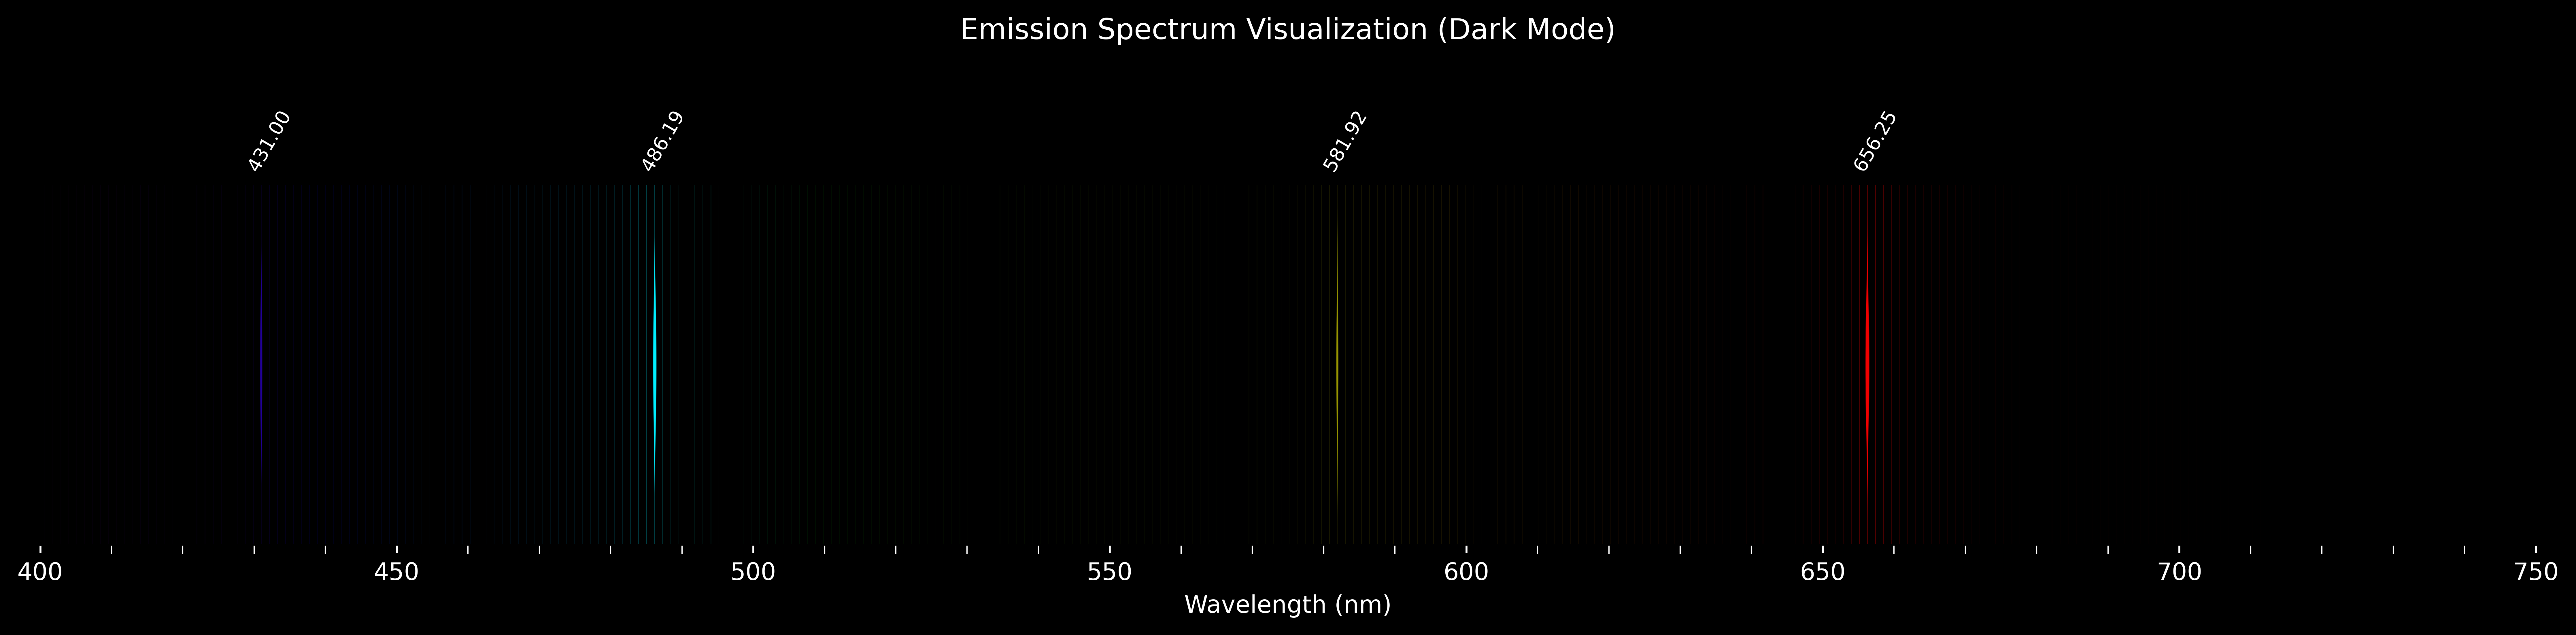

In [11]:
plot_graph()
plt.show()
